#Bibliotecas

In [18]:
import os
import copy
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm, jarque_bera, shapiro # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

In [19]:
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git
%cd /content/Mercado-Artificial-Fiis

import sys
sys.path.append('/content/Mercado-Artificial-Fiis')

!pip install numpy pandas matplotlib scipy statsmodels yfinance seaborn



Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (164/164), done.
remote: Total 176 (delta 91), reused 2 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (176/176), 2.91 MiB | 4.23 MiB/s, done.
Resolving deltas: 100% (91/91), done.
/content/Mercado-Artificial-Fiis


In [20]:
from src.simulacao import simular_mercado_e_plotar, plotar_resultado, SIM_PARAMS

In [21]:
import importlib
import src.simulacao
import src.agentes
import src.mercado

importlib.reload(src.agentes)
importlib.reload(src.mercado)
importlib.reload(src.simulacao)

from src.simulacao import simular_mercado_e_plotar, SIM_PARAMS, plotar_resultado

print("✓ Módulos recarregados")

✓ Módulos recarregados


# Rodar o Mercado

In [22]:
parametros_sistema = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/parametros_sistema_calibrados.csv').to_numpy()[0]

parametros_sistema

array([0.84822756, 0.69540723, 0.87855894, 0.15595803, 0.07548527])

In [23]:

NUM_DIAS    = 60
params = copy.deepcopy(SIM_PARAMS)

# Rodar sem plotar
resultado = simular_mercado_e_plotar(
    parametros_sistema=parametros_sistema,
    num_dias=NUM_DIAS,
    sim_params=params,
    imprimir=False,
)

Total de Agentes: 800


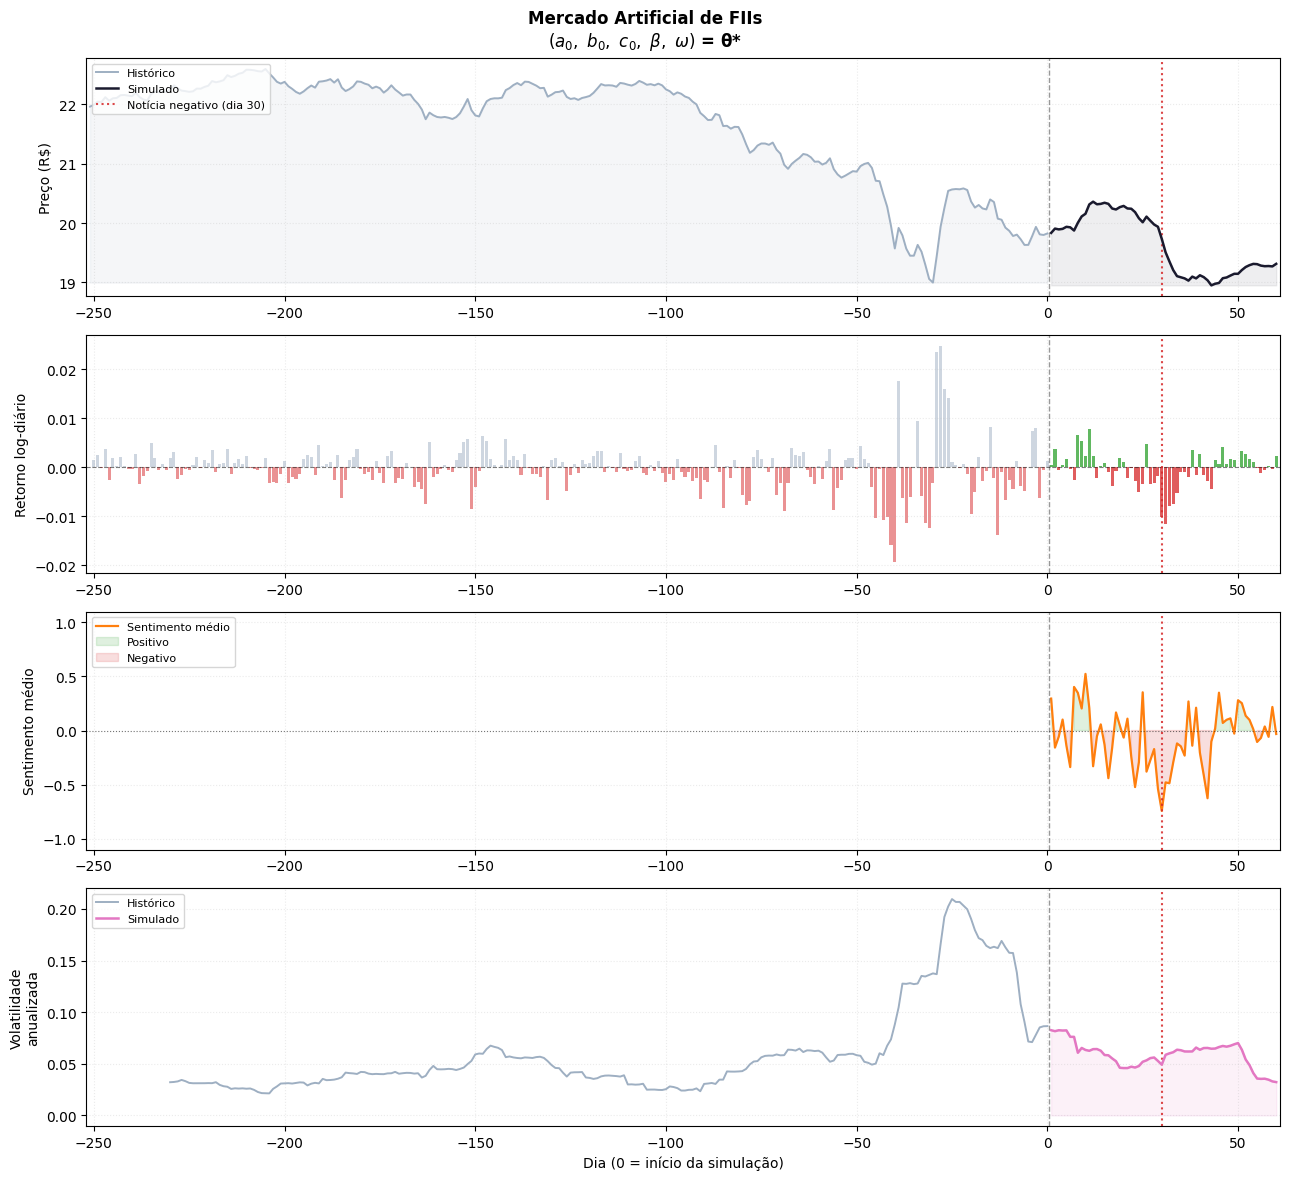

In [24]:
plotar_resultado(resultado, params=params, num_dias=NUM_DIAS)

# Referência Bootstrap

## Janela de 60 Dias

In [25]:

momentos_bootstrap_60 = pd.read_csv("/content/Mercado-Artificial-Fiis/notebooks/dados/momentos_bootstrap_60.csv")
momentos_bootstrap_60.head()

# Calcular estatísticas por coluna
df_referencia_empirica_60 = pd.DataFrame({
    "Momento": momentos_bootstrap_60.columns,
    "Média do bootstrap": momentos_bootstrap_60.mean().values,
    "DP bootstrap": momentos_bootstrap_60.std().values,
    "IC 95% inf": momentos_bootstrap_60.quantile(0.025).values,
    "IC 95% sup": momentos_bootstrap_60.quantile(0.975).values,
})

df_referencia_empirica_60

,Momento,Média do bootstrap,DP bootstrap,IC 95% inf,IC 95% sup
0,Media,0.000052,0.000646,-0.001203,0.001351
1,Variancia,0.000014,0.000008,0.000005,0.000037
2,Assimetria,0.013964,0.913351,-1.784080,2.078316
3,Curtose,5.735955,2.810985,2.787951,12.936896
4,acf_5,-0.029352,0.119243,-0.274610,0.191849
5,acf_10,-0.021469,0.113322,-0.251494,0.210195
6,acf_15,-0.017443,0.111847,-0.234302,0.212489
7,acf_20,-0.023073,0.103335,-0.240387,0.167221
8,autocorr_q_1,0.204947,0.209008,-0.092942,0.671057
9,autocorr_q_2,0.080851,0.151514,-0.155613,0.396847


## Janela de 500 Dias

In [26]:
momentos_bootstrap_500 = pd.read_csv("/content/Mercado-Artificial-Fiis/notebooks/dados/momentos_bootstrap_500.csv")
momentos_bootstrap_500.head()



,Media,Variancia,Assimetria,Curtose,acf_5,acf_10,acf_15,acf_20,autocorr_q_1,autocorr_q_2
0,0.000141,0.000011,0.666245,9.369070,0.100422,0.040643,0.009899,-0.006169,0.151660,0.214680
1,0.000399,0.000012,1.008534,9.101307,0.102057,-0.066555,-0.050478,-0.124395,0.379003,0.207572
2,0.000045,0.000010,-0.076848,6.461567,0.019966,-0.073364,-0.030344,0.025610,0.162999,0.036368
3,-0.000124,0.000020,0.751546,9.421992,0.117835,-0.053933,-0.026230,0.061686,0.454738,0.242761
4,-0.000220,0.000016,0.615142,10.042503,0.108040,0.139802,-0.033636,-0.009115,0.516478,0.201094


In [27]:
# Calcular estatísticas por coluna
df_referencia_empirica_500 = pd.DataFrame({
    "Momento": momentos_bootstrap_500.columns,
    "Média do bootstrap": momentos_bootstrap_500.mean().values,
    "DP bootstrap": momentos_bootstrap_500.std().values,
    "IC 95% inf": momentos_bootstrap_500.quantile(0.025).values,
    "IC 95% sup": momentos_bootstrap_500.quantile(0.975).values,
})

df_referencia_empirica_500

,Momento,Média do bootstrap,DP bootstrap,IC 95% inf,IC 95% sup
0,Media,0.000031,0.000243,-0.000454,0.000512
1,Variancia,0.000014,0.000003,0.000009,0.000021
2,Assimetria,0.154954,0.667821,-0.854268,1.531713
3,Curtose,8.651156,2.518067,4.243442,13.694373
4,acf_5,0.070739,0.062490,-0.051118,0.190350
5,acf_10,-0.006074,0.047246,-0.093547,0.088684
6,acf_15,-0.005999,0.046735,-0.101424,0.085490
7,acf_20,-0.002012,0.047080,-0.095975,0.088147
8,autocorr_q_1,0.368042,0.178912,0.086816,0.633222
9,autocorr_q_2,0.244271,0.118946,0.008504,0.429600


# Funções usadas

## Momentos Simulação

In [28]:
def momentos_simulacao(ret):
    """Calcula os 10 fatos estilizados de uma série de retornos."""
    if len(ret) < 50:
        return [np.nan] * 10
    ret2 = ret ** 2
    try:
        acf_r  = acf(ret,  nlags=20, fft=True, missing='drop')
        acf_r2 = acf(ret2, nlags=2,  fft=True, missing='drop')
    except Exception:
        acf_r  = np.full(21, np.nan)
        acf_r2 = np.full(3,  np.nan)
    return [
        float(np.mean(ret)),
        float(np.var(ret)),
        float(skew(ret, nan_policy='omit')),
        float(kurtosis(ret, fisher=False, nan_policy='omit')),
        float(acf_r[5])  if len(acf_r) > 5  else np.nan,
        float(acf_r[10]) if len(acf_r) > 10 else np.nan,
        float(acf_r[15]) if len(acf_r) > 15 else np.nan,
        float(acf_r[20]) if len(acf_r) > 20 else np.nan,
        float(acf_r2[1]) if len(acf_r2) > 1 else np.nan,
        float(acf_r2[2]) if len(acf_r2) > 2 else np.nan,
    ]

NOMES_MOMENTOS = [
    "Média", "Variância", "Assimetria", "Curtose",
    "ACF lag 5", "ACF lag 10", "ACF lag 15", "ACF lag 20",
    "ACF² lag 1", "ACF² lag 2"
]

## Cobertura mcr

In [29]:
def cobertura_mcr(
    df_simulacoes: pd.DataFrame,
    df_unica: pd.DataFrame,
    num_dias: int,
    col_sim: str = "simulacao",
    col_retorno: str = "log_return",
    lags_acf: list = [5, 10, 15, 20],
    lags_acf2: list = [1, 2],
    fft: bool = True,
) -> tuple[pd.DataFrame, float, pd.DataFrame]:

    sims = df_simulacoes[col_sim].unique()
    momentos_ref = df_unica["Momento"].astype(str).tolist()
    ic = df_unica.set_index("Momento")[["IC 95% inf", "IC 95% sup"]].to_dict("index")

    hits = {m: 0 for m in momentos_ref}
    joint_hits = 0
    flags_rows = []

    for k in sims:
        df_k = df_simulacoes[df_simulacoes[col_sim] == k].tail(num_dias)
        r = df_k[col_retorno].to_numpy(dtype=float)
        r = r[np.isfinite(r)]

        # Calcular momentos com nomes iguais ao df_unica
        m_sim = {}
        m_sim["Media"]      = float(np.mean(r))
        m_sim["Variancia"]  = float(np.var(r, ddof=1))
        m_sim["Assimetria"] = float(skew(r, bias=False))
        m_sim["Curtose"]    = float(kurtosis(r, fisher=False, bias=False))

        acf_r = acf(r, nlags=max(lags_acf), fft=fft)
        for L in lags_acf:
            m_sim[f"acf_{L}"] = float(acf_r[L])

        acf_q = acf(r**2, nlags=max(lags_acf2), fft=fft)
        for L in lags_acf2:
            m_sim[f"autocorr_q_{L}"] = float(acf_q[L])

        # Avaliar cobertura
        all_inside = True
        row_flags = {"simulacao": k}

        for m in momentos_ref:
            val = m_sim.get(m, np.nan)
            lo = ic[m]["IC 95% inf"]
            hi = ic[m]["IC 95% sup"]

            inside = np.isfinite(val) and (val >= lo) and (val <= hi)
            row_flags[m] = inside
            hits[m] += int(inside)
            all_inside = all_inside and inside

        row_flags["joint"] = all_inside
        flags_rows.append(row_flags)
        joint_hits += int(all_inside)

    n_sim = len(sims)
    df_cob = pd.DataFrame({
        "Momento": momentos_ref,
        "Cobertura (%)": [100 * hits[m] / n_sim for m in momentos_ref]
    })
    joint_mcr = 100 * joint_hits / n_sim
    df_flags = pd.DataFrame(flags_rows)

    return df_cob, joint_mcr, df_flags

## Plotar Momentos

In [30]:
def plotar_distribuicoes_momentos(
    df_momentos_sim,
    df_unica,
    col_sim="simulacao",
    col_momento_ref="Momento",
    col_media_ref="Média do bootstrap",
    col_ic_inf="IC 95% inf",
    col_ic_sup="IC 95% sup",
    bins=30,
    density=True,
    figsize=(8, 4.8)
):
    """
    Gera um gráfico para cada momento:
    histograma das simulações + média bootstrap + faixa IC95%.
    """
    momentos = df_unica[col_momento_ref].tolist()

    for momento in momentos:
        if momento not in df_momentos_sim.columns:
            print(f"Aviso: momento '{momento}' não encontrado nas simulações. Pulando.")
            continue

        valores = df_momentos_sim[momento].dropna().to_numpy(dtype=float)

        linha_ref = df_unica[df_unica[col_momento_ref] == momento].iloc[0]
        media_boot = linha_ref[col_media_ref]
        ic_inf = linha_ref[col_ic_inf]
        ic_sup = linha_ref[col_ic_sup]

        plt.figure(figsize=figsize)
        plt.hist(valores, bins=bins, density=density, alpha=0.6, edgecolor="black")

        plt.axvline(media_boot, linestyle="--", linewidth=2, label="Média bootstrap")
        plt.axvspan(ic_inf, ic_sup, alpha=0.2, label="IC 95% bootstrap")

        plt.title(f"Distribuição simulada de {momento}")
        plt.xlabel(momento)
        plt.ylabel("Densidade" if density else "Frequência")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

## Taxa de Cobertura

In [31]:
def taxa_cobertura(parametros_sistema, num_dias, n_simulacoes, df_resultado):
    """
    Roda o mercado n vezes e avalia se os momentos caem dentro dos ICs obtidos pelo bootstrap.

    Args:
        parametros_sistema: parâmetros do simulador
        num_dias: número de dias da simulação
        n_simulacoes: número de rodadas
        df_resultado: DataFrame com ICs (colunas: Momento, IC 95% inf, IC 95% sup)

    Retorna:
        DataFrame com índice de cobertura (proporção de vezes em que o momento ficou dentro do IC).
    """
    col_momento = "Momento"
    col_inf     = "IC 95% inf"
    col_sup     = "IC 95% sup"

    # Inicializa contadores
    cobertura = {nome: 0 for nome in df_resultado[col_momento]}

    for i in range(n_simulacoes):
        try:
            _, log_returns, _, _, _ = simular_mercado_e_plotar(
                parametros_sistema, num_dias, imprimir=False)

            momentos_sim = momentos_simulacao(log_returns[-num_dias:])

            for j, nome in enumerate(df_resultado[col_momento]):
                ic_inf = df_resultado.loc[df_resultado[col_momento] == nome, col_inf].values[0]
                ic_sup = df_resultado.loc[df_resultado[col_momento] == nome, col_sup].values[0]
                if ic_inf <= momentos_sim[j] <= ic_sup:
                    cobertura[nome] += 1

        except Exception as e:
            print(f"[SIM {i}] Erro: {e}")
            continue

    df_cobertura = pd.DataFrame([
        {col_momento: nome, "Cobertura": count / n_simulacoes}
        for nome, count in cobertura.items()
    ])

    plt.figure(figsize=(10, 4))
    plt.bar(df_cobertura[col_momento], df_cobertura["Cobertura"],
            color="skyblue", edgecolor="black")
    plt.axhline(0.95, color="red", linestyle="--", label="Nível nominal 95%")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Proporção de Cobertura")
    plt.title("Cobertura dos Intervalos de Confiança por Momento")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_cobertura

## Avaliar Cobertura

In [33]:
def avaliar_cobertura(parametros_sistema, num_dias, n_simulacoes, df_resultado,
                      path_salvar=None, path_series=None):
    """
    Args:
        ...
        path_salvar:  caminho para salvar o CSV de cobertura (opcional)
        path_series:  caminho para salvar o CSV com todas as séries de preços (opcional)
    """
    col_momento = "Momento"
    col_inf     = "IC 95% inf"
    col_sup     = "IC 95% sup"

    cobertura = {nome: 0 for nome in df_resultado[col_momento]}
    series_precos = []

    for i in range(n_simulacoes):
        try:
            historico_precos, log_returns, _, _, _ = simular_mercado_e_plotar(
                parametros_sistema, num_dias, imprimir=False)

            # Salvar série de preços da rodada
            print(f"historico_precos: {len(historico_precos)}, log_returns: {len(log_returns)}")
            df_serie = pd.DataFrame({
                "simulacao": i + 1,
                "dia":       range(1, len(historico_precos) + 1),
                "preco_fii":     historico_precos,
                "log_return":     [np.nan] + list(log_returns),

            })
            series_precos.append(df_serie)

            momentos_sim = momentos_simulacao(log_returns[-num_dias:])

            print(f"\n=== Simulação {i+1}/{n_simulacoes} ===")
            for j, nome in enumerate(df_resultado[col_momento]):
                valor  = momentos_sim[j]
                ic_inf = df_resultado.loc[df_resultado[col_momento] == nome, col_inf].values[0]
                ic_sup = df_resultado.loc[df_resultado[col_momento] == nome, col_sup].values[0]

                dentro = ic_inf <= valor <= ic_sup
                status = "✅ dentro" if dentro else "❌ fora"
                print(f"{nome}: {valor:.4f} | IC95% [{ic_inf:.4f}, {ic_sup:.4f}] → {status}")

                if dentro:
                    cobertura[nome] += 1

        except Exception as e:
            print(f"[SIM {i}] Erro: {e}")
            continue

    df_cobertura = pd.DataFrame([
        {col_momento: nome, "Cobertura": count / n_simulacoes}
        for nome, count in cobertura.items()
    ])

    if path_salvar:
        df_cobertura.to_csv(path_salvar, index=False)
        print(f"\n✓ Cobertura salva em: {path_salvar}")

    if path_series and series_precos:
        df_todas_series = pd.concat(series_precos, ignore_index=True)
        df_todas_series.to_csv(path_series, index=False)
        print(f"✓ Séries salvas em: {path_series} — shape: {df_todas_series.shape}")

    plt.figure(figsize=(10, 4))
    plt.bar(df_cobertura[col_momento], df_cobertura["Cobertura"],
            color="skyblue", edgecolor="black")
    plt.axhline(0.95, color="red", linestyle="--", label="Nível nominal 95%")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Proporção de Cobertura")
    plt.title("Cobertura dos Intervalos de Confiança por Momento")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_cobertura

# Simulações - Janelas de 60 dias

Total de Agentes: 800
⚡ Choque aleatório negativo no dia 7 (intensidade 0.32)
⚡ Choque aleatório negativo no dia 16 (intensidade 0.41)
⚡ Choque aleatório negativo no dia 51 (intensidade 0.38)
⚡ Choque aleatório negativo no dia 54 (intensidade 0.38)
⚡ Choque aleatório negativo no dia 57 (intensidade 0.46)
historico_precos: 312, log_returns: 311

=== Simulação 1/50 ===
Media: -0.0013 | IC95% [-0.0012, 0.0014] → ❌ fora
Variancia: 0.0000 | IC95% [0.0000, 0.0000] → ✅ dentro
Assimetria: -0.1035 | IC95% [-1.7841, 2.0783] → ✅ dentro
Curtose: 2.7804 | IC95% [2.7880, 12.9369] → ❌ fora
acf_5: 0.0716 | IC95% [-0.2746, 0.1918] → ✅ dentro
acf_10: -0.2993 | IC95% [-0.2515, 0.2102] → ❌ fora
acf_15: -0.2644 | IC95% [-0.2343, 0.2125] → ❌ fora
acf_20: 0.0710 | IC95% [-0.2404, 0.1672] → ✅ dentro
autocorr_q_1: 0.2914 | IC95% [-0.0929, 0.6711] → ✅ dentro
autocorr_q_2: 0.0421 | IC95% [-0.1556, 0.3968] → ✅ dentro
Total de Agentes: 800
⚡ Choque aleatório positivo no dia 5 (intensidade 0.33)
⚡ Choque aleatório 

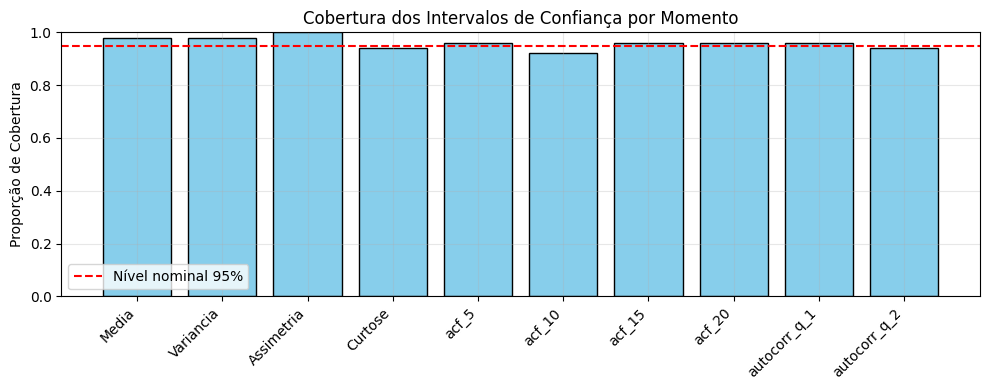

        Momento  Cobertura
0         Media       0.98
1     Variancia       0.98
2    Assimetria       1.00
3       Curtose       0.94
4         acf_5       0.96
5        acf_10       0.92
6        acf_15       0.96
7        acf_20       0.96
8  autocorr_q_1       0.96
9  autocorr_q_2       0.94


In [34]:
num_dias = 60

df_cobertura = avaliar_cobertura(
    parametros_sistema=parametros_sistema,
    num_dias=60,
    n_simulacoes=50,
    df_resultado=df_referencia_empirica_60,
    path_salvar="/content/cobertura_60dias.csv",
    path_series="/content/series_60dias.csv"
)

print(df_cobertura)

# Simulações - Janela de 500 dias

Total de Agentes: 800
⚡ Choque aleatório negativo no dia 79 (intensidade 0.42)
Imovel atualizado: Valor: R$1,083,437.84
Imovel atualizado: Valor: R$2,153,437.84
[FII] Imóveis atualizados; reinvestido: R$26,875.69
⚡ Choque aleatório negativo no dia 203 (intensidade 0.69)
⚡ Choque aleatório positivo no dia 212 (intensidade 0.38)
⚡ Choque aleatório negativo no dia 232 (intensidade 0.67)
Imovel atualizado: Valor: R$1,167,008.19
Imovel atualizado: Valor: R$2,311,908.19
[FII] Imóveis atualizados; reinvestido: R$15,459.40
⚡ Choque aleatório negativo no dia 343 (intensidade 0.54)
⚡ Choque aleatório negativo no dia 344 (intensidade 0.56)
⚡ Choque aleatório negativo no dia 369 (intensidade 0.32)
Imovel atualizado: Valor: R$1,253,650.24
Imovel atualizado: Valor: R$2,478,693.24
[FII] Imóveis atualizados; reinvestido: R$9,902.95
⚡ Choque aleatório negativo no dia 391 (intensidade 0.38)
⚡ Choque aleatório negativo no dia 397 (intensidade 0.39)
historico_precos: 752, log_returns: 751

=== Simulação 1

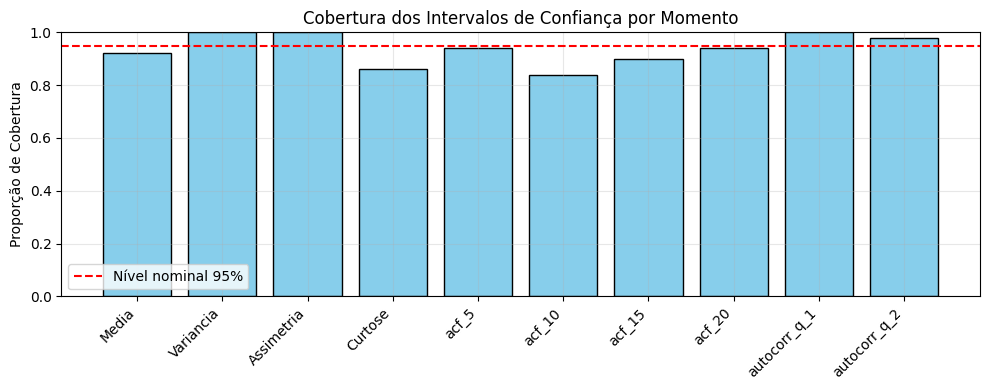

        Momento  Cobertura
0         Media       0.92
1     Variancia       1.00
2    Assimetria       1.00
3       Curtose       0.86
4         acf_5       0.94
5        acf_10       0.84
6        acf_15       0.90
7        acf_20       0.94
8  autocorr_q_1       1.00
9  autocorr_q_2       0.98


In [ ]:
df_cobertura_500 = avaliar_cobertura(
    parametros_sistema=parametros_sistema,
    num_dias=500,
    n_simulacoes=50,
    df_resultado=df_referencia_empirica_500,
    path_salvar="/content/cobertura_500dias.csv",
    path_series="/content/series_500dias.csv"
)

print(df_cobertura_500)

#Juntar simulações

In [ ]:
def juntar_simulacoes(df1, df2, df3, df4, col_sim="simulacao"):
    """
    Junta três dataframes de simulações e renumera
    as simulações de 1 até N total.
    """

    # Copiar para evitar alterar originais
    df1 = df1.copy()
    df2 = df2.copy()
    df3 = df3.copy()
    df4 = df4.copy()

    # Quantidade de simulações únicas em cada
    n1 = df1[col_sim].nunique()
    n2 = df2[col_sim].nunique()
    n3 = df3[col_sim].nunique()
    n4 = df4[col_sim].nunique()

    # Renumerar df2
    df2[col_sim] += n1

    # Renumerar df3
    df3[col_sim] += (n1 + n2)

    #Reenumerar df4
    df4[col_sim] += (n1 + n2 + n3)

    # Concatenar
    df_total = pd.concat([df1, df2, df3, df4], ignore_index=True)

    return df_total

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
import os

# 🔹 Monte o Google Drive (somente no Colab)
#drive.mount('/content/drive')

# 🔹 Caminho da pasta onde salvar os resultados
save_dir = "/content/drive/MyDrive/Doutorado/simulacoes_fii_2"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
import os

# List the contents of the save_dir
files_in_dir = os.listdir(save_dir)
print(f"Files in '{save_dir}':")
for f in files_in_dir:
    print(f)



Files in '/content/drive/MyDrive/Doutorado/simulacoes_fii_2':
resultados_fii_60dias_calib2_10sim.csv
resultados_fii_60dias_calib2_100sim.csv
resultados3_fii_60dias_calib2_300sim.csv
resultados2_fii_60dias_calib2_100sim.csv
resultados_fii_500dias_calib2_100sim.csv
resultados2_fii_500dias_calib2_100sim.csv
resultados3_fii_500dias_calib2_100sim.csv


In [ ]:
file_to_read_1 = "resultados_fii_500dias_calib2_100sim.csv"
full_path_1 = os.path.join(save_dir, file_to_read_1)
df_resultados1 = pd.read_csv(full_path_1)

file_to_read_2 = "resultados2_fii_500dias_calib2_100sim.csv"
full_path_2 = os.path.join(save_dir, file_to_read_2)
df_resultados2 = pd.read_csv(full_path_2)

file_to_read_3 = "resultados3_fii_500dias_calib2_100sim.csv"
full_path_3 = os.path.join(save_dir, file_to_read_3)
df_resultados3 = pd.read_csv(full_path_3)

df_resultados4 = pd.read_csv('/content/series_500dias.csv')

In [ ]:
file_to_read_1 = "resultados_fii_60dias_calib2_100sim.csv"
full_path_1 = os.path.join(save_dir, file_to_read_1)
df_resultados1 = pd.read_csv(full_path_1)

file_to_read_2 = "resultados2_fii_60dias_calib2_100sim.csv"
full_path_2 = os.path.join(save_dir, file_to_read_2)
df_resultados2 = pd.read_csv(full_path_2)

file_to_read_3 = "resultados3_fii_60dias_calib2_300sim.csv"
full_path_3 = os.path.join(save_dir, file_to_read_3)
df_resultados3 = pd.read_csv(full_path_3)

df_resultados4 = pd.read_csv('/content/series_60dias.csv')

In [ ]:
df_resultados = juntar_simulacoes(
    df_resultados1,
    df_resultados2,
    df_resultados3,
    df_resultados4


)

print("Total de simulações:", df_resultados["simulacao"].nunique())

Total de simulações: 350


In [ ]:
df_resultados

,simulacao,dia,preco_fii,log_return,vol_rolante,midia_valor,sentimento_medio
0,1,0,21.963884,NaN,NaN,NaN,0.240983
1,1,1,21.993913,0.001366,NaN,NaN,0.271151
2,1,2,22.048098,0.002461,NaN,NaN,0.415142
3,1,3,22.042092,-0.000272,NaN,NaN,0.349544
4,1,4,22.122676,0.003649,NaN,NaN,0.299774
...,...,...,...,...,...,...,...
263195,350,748,25.626726,0.004711,NaN,NaN,NaN
263196,350,749,25.653832,0.001057,NaN,NaN,NaN
263197,350,750,25.733652,0.003107,NaN,NaN,NaN
263198,350,751,25.787749,0.002100,NaN,NaN,NaN
